In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# 1. Dataset overview

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "raw"
FAKE_PATH = RAW_PATH / Path("DFD_manipulated_sequences")
REAL_PATH = RAW_PATH / Path("DFD_original_sequences")

print(f"RAW_PATH: {RAW_PATH}")
print(f"REAL_PATH: {REAL_PATH}")
print(f"FAKE_PATH: {FAKE_PATH}")

RAW_PATH: d:\deepfake-detection\data\raw
REAL_PATH: d:\deepfake-detection\data\raw\DFD_original_sequences
FAKE_PATH: d:\deepfake-detection\data\raw\DFD_manipulated_sequences


In [3]:
original_count = len(glob(str(REAL_PATH / "*.mp4")))
manipulated_count = len(glob(str(FAKE_PATH / "*.mp4")))

print(f"Original: {original_count}")
print(f"Manipulated: {manipulated_count}")

Original: 363
Manipulated: 3068


# 2. Video class distribution   

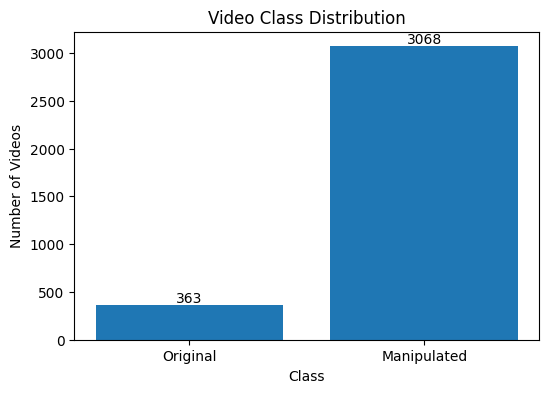

In [4]:
labels = ["Original", "Manipulated"]
counts = [original_count, manipulated_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts)

plt.title("Video Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Videos")

# ghi số lượng lên đầu cột
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha="center", va="bottom")

# 3. FPS analysis

In [5]:
real_videos = glob(str(REAL_PATH / "*.mp4"))
fake_videos = glob(str(FAKE_PATH / "*.mp4"))

def get_fps(video_path):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

real_fps = [get_fps(v) for v in real_videos]
fake_fps = [get_fps(v) for v in fake_videos]

print(f"Distinct FPS values in original videos: {sorted(set(real_fps))}")
print(f"Distinct FPS values in manipulated videos: {sorted(set(fake_fps))}")

Distinct FPS values in original videos: [24.0]
Distinct FPS values in manipulated videos: [24.0]


> All videos in both datasets have the identical frame rate of 24.0 FPS

# 3. Video duration distribution


In [6]:
smaller_than_15f = pd.DataFrame(columns=["video_path", "duration"])

def get_video_duration(video_path):
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    cap.release()

    if fps == 0:
        return 0

    duration = frames / fps

    if duration < 15/24:
        smaller_than_15f.loc[len(smaller_than_15f)] = [video_path, duration]

    return duration



real_duration = [get_video_duration(v) for v in real_videos]
fake_duration = [get_video_duration(v) for v in fake_videos]

all_duration = real_duration + fake_duration

print(f"Average real duration : {np.mean(real_duration):.2f} s")
print(f"Average fake duration : {np.mean(fake_duration):.2f} s")
print(f"Average overall       : {np.mean(all_duration):.2f} s")
print(f"Minimum duration      : {np.min(all_duration):.2f} s")
print(f"Maximum duration      : {np.max(all_duration):.2f} s")

Average real duration : 36.20 s
Average fake duration : 30.46 s
Average overall       : 31.07 s
Minimum duration      : 0.21 s
Maximum duration      : 67.50 s


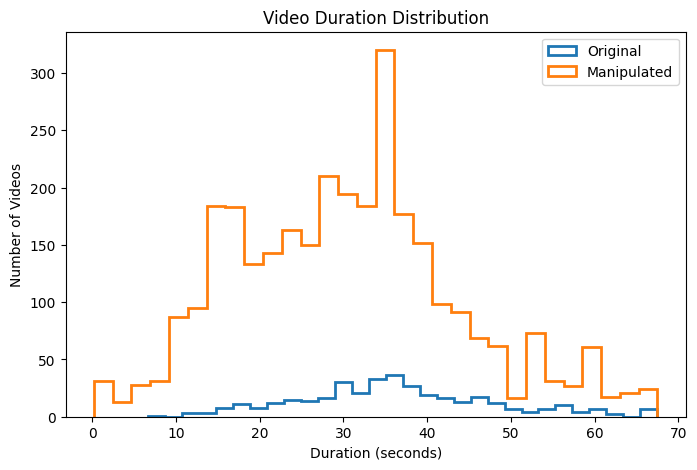

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(real_duration, bins=30, histtype="step", linewidth=2, label="Original")

plt.hist(fake_duration, bins=30, histtype="step", linewidth=2, label="Manipulated")

plt.title("Video Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Videos")

plt.legend()
plt.show()

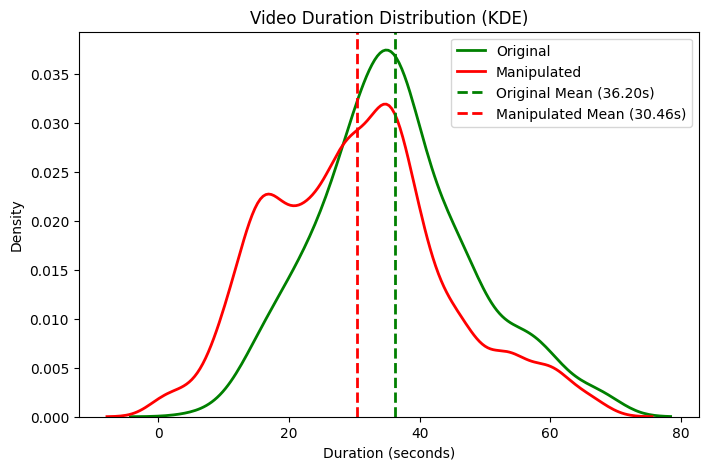

In [8]:
plt.figure(figsize=(8, 5))

sns.kdeplot(real_duration, label="Original", linewidth=2, color="green")
sns.kdeplot(fake_duration, label="Manipulated", linewidth=2, color="red")

real_mean = np.mean(real_duration)
fake_mean = np.mean(fake_duration)

plt.axvline(
    real_mean, linestyle="--", linewidth=2, color = "green",label=f"Original Mean ({real_mean:.2f}s)"
)

plt.axvline(
    fake_mean, linestyle="--", linewidth=2, color = "red",label=f"Manipulated Mean ({fake_mean:.2f}s)"
)

plt.title("Video Duration Distribution (KDE)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")

plt.legend()
plt.show()

> **Insight**

The duration distributions of the two classes overlap considerably, suggesting that **video duration alone is not a reliable feature** for deepfake detection. However, original videos are generally longer (36.20 s vs. 30.46 s), while manipulated videos exhibit a bimodal distribution, indicating greater variability in video lengths.

In [9]:
for i in range(len(smaller_than_15f)):
    print(smaller_than_15f.video_path.iloc[i])

d:\deepfake-detection\data\raw\DFD_manipulated_sequences\01_09__secret_conversation__SJZRV69J.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\01_11__secret_conversation__WIZ7GKOD.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\01_20__secret_conversation__FW94AIMJ.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_06__secret_conversation__F3I4PDYF.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_13__secret_conversation__2TM4IFSF.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_15__secret_conversation__N0SRODQD.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_20__secret_conversation__B0X1CGG2.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_20__secret_conversation__VD7BCF1U.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\12_21__secret_conversation__J54W3PV1.mp4
d:\deepfake-detection\data\raw\DFD_manipulated_sequences\24_19__secret_conversation__NPZW2Z9L.mp4
d:\deepfake-detectio